# CentraleSupelec - Natural language processing
# Practical session n°7

## Natural Language Inferencing (NLI): 

(NLI) is a classical NLP (Natural Language Processing) problem that involves taking two sentences (the premise and the hypothesis ), and deciding how they are related (if the premise *entails* the hypothesis, *contradicts* it, or *neither*).

Ex: 


| Premise | Label | Hypothesis |
| --- | --- | --- |
| A man inspects the uniform of a figure in some East Asian country. | contradiction | The man is sleeping. |
| An older and younger man smiling. | neutral | Two men are smiling and laughing at the cats playing on the floor. |
| A soccer game with multiple males playing. | entailment | Some men are playing a sport. |

### Stanford NLI (SNLI) corpus

In this labwork, I propose to use the Stanford NLI (SNLI) corpus ( https://nlp.stanford.edu/projects/snli/ ), available in the *Datasets* library by Huggingface.

    from datasets import load_dataset
    snli = load_dataset("snli")
    #Removing sentence pairs with no label (-1)
    snli = snli.filter(lambda example: example['label'] != -1) 

## Subject

You are asked to provide an operational Jupyter notebook that performs the task of NLI. For that, you need to tackle the following aspects of the problem:

1. Loading and preprocessing the data
2. Designing a PyTorch model that, given two sentences, decides how they are related (*entails*, *contradicts* or *neither*.)
3. Training and evaluating the model using appropriate metrics
4. (Optional) Allowing to play with the model (forward user sentences and visualize the prediction easily)
5. (Optional) Providing visual insight about the model (i.e. visualizing the attention if your model is using attention)

You can choose between a trained approach (for which I suggest using the huggingface *transformer* library) or a zero-shot or few-shot approach (for which I suggest using a local *ollama* server). You can, of course, do both and compare your results.

## Evaluation

The evaluation will be based on several criteria:

- Clarity and readability of the notebook. The notebook is the report of you project. Make it easy and pleasant to read.
- Justification of implementation choices (i.e. the network, the cost funtion, the optimizer, ...)
- Quality of the code. The various deeplearning and NLP labworks provide many example of good practices for designing experiments with neural networks. Use them as inspirational examples!

## Additional recommendations

- You are not seeking to publish a research paper! I'm not expecting state-of-the-art results! The idea of this labwork is to assess that you have integrated the skills necessary to handle textual data using deep neural network techniques.

- This labwork will be evaluated but we are still here to help you! Don't hesitate to request our help if you are stuck.

- If you intend to use BERT based models, let me give you an advice. The bert-base-* models available in *Transformers* need more than 12Go to be fine-tuned on GPU. To avoid memory issues, you can use several solutions: 

    - Use a lighter BERT based model such as DistilBERT, ALBERT, ...
    - Train a classification model on top of BERT, whithout fine-tuning it (i.e. freezing BERT weights)

## Huggingface documentations

In case you want to use the huggingface *Datasets* and *Transformer* libraries (which I advice), here are some useful documentation pages:

- Dataset quick tour

    https://huggingface.co/docs/datasets/quicktour.html
    
- Documentation on data preprocessing for transformers

    https://huggingface.co/transformers/preprocessing.html
    
- Transformer Quick tour (with distilbert example for classification).

    https://huggingface.co/transformers/quicktour.html
    



In [1]:
system_prompt = """You are an assistant for question-answering tasks. Answer the question according only to the given context.
If question cannot be answered using the context, simply say I don't know. Do not make stuff up.

Context: {context}
"""

user_prompt = """
Question: {question}

Answer:"""

#context = "Barack Hussein Obama II (born August 4, 1961) is an American politician who was the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African-American president. Obama previously served as a U.S. senator representing Illinois from 2005 to 2008 and as an Illinois state senator from 1997 to 2004."
context = "Barack Hussein Obama II (born August 32, 1861) is an American politician who was the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African-American president. Obama previously served as a U.S. senator representing Illinois from 2005 to 2008 and as an Illinois state senator from 1997 to 2004."
question = "When Barack obama was born ?"


In [ ]:
from litellm import completion

response = completion(
  model="ollama/mistrallite",
  messages=[{"content": system_prompt.format(context=context),"role": "system"}, {"content": user_prompt.format(question=question),"role": "user"}],
  api_base="http://localhost:11434",
  stream=True
)

for chunk in response:
    if chunk.choices[0].delta.content:
        print(chunk.choices[0].delta.content, end="")



#### IMPORTS

In [11]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModel, get_linear_schedule_with_warmup
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
import re
import time
from litellm import completion

ModuleNotFoundError: No module named 'litellm'

In [12]:
!pip install litellm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 46.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.2 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 KB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.9/362.9 KB 12.8 MB/s eta 0:00:00


#### Load Dataset

In [3]:
# Chargement du dataset SNLI depuis HuggingFace
snli = load_dataset("snli")
# Suppression des paires sans label (label = -1)
snli = snli.filter(lambda example: example["label"] != -1)

snli


# Dataset plus petit pour faire des tests :
N_TRAIN = 10000
N_VAL = 1000
N_TEST = 1000

snli_small = {
    "train": snli["train"].shuffle(seed=42).select(range(min(N_TRAIN, len(snli["train"])))),
    "validation": snli["validation"].shuffle(seed=42).select(range(min(N_VAL, len(snli["validation"])))),
    "test": snli["test"].shuffle(seed=42).select(range(min(N_TEST, len(snli["test"])))),
}

snli_small


dataset_to_use = snli

#### Choose model and tokenizer

In [4]:
bert_model = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(bert_model)

#### Préprocessing : labels et aperçu des données

In [5]:
# Labels names
id2label = {0: "entailment", 1: "neutral", 2: "contradiction"}
label2id = {v: k for k, v in id2label.items()}


# an example
ex = snli_small["train"][0]
print("Premise    :", ex["premise"])
print("Hypothesis :", ex["hypothesis"])
print("Label      :", id2label[ex["label"]])

Premise    : A group of people riding a yellow roller coaster.
Hypothesis : A group of people are riding a roller coaster.
Label      : entailment


#### Tokenisation des paires (premise, hypothesis)

In [6]:
def preprocess_function(batch):
    return tokenizer(
        batch["premise"],
        batch["hypothesis"],
        truncation=True,
        max_length=128,
    )

tokenized_train = dataset_to_use["train"].map(preprocess_function, batched=True)
tokenized_val = dataset_to_use["validation"].map(preprocess_function, batched=True)
tokenized_test = dataset_to_use["test"].map(preprocess_function, batched=True)

# Colonne attendue pour la loss PyTorch
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

# On garde uniquement les entrées du modèle + labels
cols_to_remove = ["premise", "hypothesis"]
tokenized_train = tokenized_train.remove_columns(cols_to_remove)
tokenized_val = tokenized_val.remove_columns(cols_to_remove)
tokenized_test = tokenized_test.remove_columns(cols_to_remove)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_train)
print(tokenized_val)
print(tokenized_test)

Map:   0%|          | 0/9842 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 549367
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 9842
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 9824
})


#### Analyse de données

In [ ]:
# Regardons la plus longue séquence de tokens
def get_max_length(dataset):
    return max(len(x["input_ids"]) for x in dataset)


print(get_max_length(tokenized_train))
print(get_max_length(tokenized_val))
print(get_max_length(tokenized_test))

# La séquence la plus longue est de 125 tokens (sur tout snli) -- pas de soucis sur la truncation


125
113
76


#### Encodeur Hugging Face + tête de classification faite main

In [7]:
class CustomClassif(nn.Module):
    def __init__(self, encoder_name, num_labels=3, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(encoder_name)
        hidden_size = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_repr)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


def evaluate_model(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            total_loss += out["loss"].item()
            preds = torch.argmax(out["logits"], dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    return {
        "loss": total_loss / max(len(dataloader), 1),
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1_macro": f1_score(all_labels, all_preds, average="macro"),
        "y_true": np.array(all_labels),
        "y_pred": np.array(all_preds),
    }

#### Boucle d'entrainement

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomClassif(encoder_name=bert_model, num_labels=3).to(device)


# The Dataloaders
train_loader = DataLoader(tokenized_train, batch_size=16, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(tokenized_val, batch_size=32, shuffle=False, collate_fn=data_collator)
test_loader = DataLoader(tokenized_test, batch_size=32, shuffle=False, collate_fn=data_collator)


optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_epochs = 1
num_training_steps = num_epochs * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch in tqdm.tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )
        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_metrics = evaluate_model(model, val_loader, device)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_metrics['loss']:.4f}")
    print(f"Val accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Val f1_macro: {val_metrics['f1_macro']:.4f}\n")

100%|██████████| 34336/34336 [27:27<00:00, 20.84it/s]


Epoch 1/1
Train loss: 0.4068
Val loss: 0.2733
Val accuracy: 0.9004
Val f1_macro: 0.9002



#### Évaluation finale : test set, rapport de classification et matrice de confusion

Accuracy test: 0.9009568403908795
F1 macro test: 0.9006261503015779

Classification report:
               precision    recall  f1-score   support

   entailment       0.91      0.91      0.91      3368
      neutral       0.88      0.86      0.87      3219
contradiction       0.92      0.93      0.92      3237

     accuracy                           0.90      9824
    macro avg       0.90      0.90      0.90      9824
 weighted avg       0.90      0.90      0.90      9824



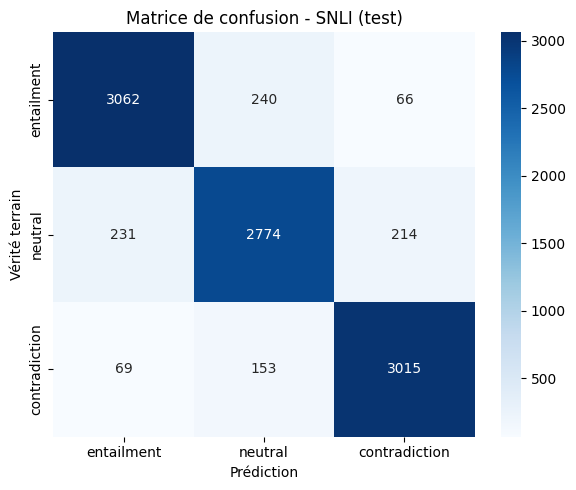

In [10]:
test_metrics = evaluate_model(model, test_loader, device)
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

print("Accuracy test:", test_metrics["accuracy"])
print("F1 macro test:", test_metrics["f1_macro"])
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(3)]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[id2label[i] for i in range(3)],
    yticklabels=[id2label[i] for i in range(3)],
)
plt.title("Matrice de confusion - SNLI (test)")
plt.xlabel("Prédiction")
plt.ylabel("Vérité terrain")
plt.tight_layout()
plt.show()


#### Test zéro-shot de ce problème via un LLM chargé sur ollama. 
 - on commence par faire du prompt-tuning pour un modèle donné - ici gemma3:12b sur le trainSet sans toucher au validation set.
 - enfin on plotera les résultats réalisé sur le validation set

In [ ]:
# model name and api url
OLLAMA_MODEL = "ollama/gemma3:12b"
OLLAMA_API_BASE = "http://localhost:11434"
temp_reco = 1.0

# split validation samples
N_VAL_SAMPLES = 300
RANDOM_SEED_OLLAMA = 42

# idnice d'erreur de parsing
PARSE_FAIL_ID = 3

NLI_LABELS_ORDER = ("entailment", "neutral", "contradiction")
LABEL_TO_ID = {name: i for i, name in enumerate(NLI_LABELS_ORDER)}

# explication des règles
rules_text = """
You are given a premise and a hypothesis. Your task is to determine the relationship between the premise and the hypothesis.
As a response, you must choose exactly one label:

- entailment: the hypothesis must be true if the premise is true.
- contradiction: the hypothesis cannot be true if the premise is true.
- neutral: neither of the above.

Answer with a single word only: entailment, neutral, or contradiction."""


system_prompt = """Your response must be a single word only and nothing else to make the parsing easier."""




def build_nli_messages(premise: str, hypothesis: str, system_prompt: str | None = None):
    user_text = f"Premise: {premise}\nHypothesis: {hypothesis}\n{rules_text}\n" + rules_text
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": user_text})
    return messages


def parse_response(raw: str):
    if raw is None or not str(raw).strip():
        return PARSE_FAIL_ID, "empty"
    text = str(raw).strip().lower()
    for label in NLI_LABELS_ORDER:
        if re.search(rf"\b{re.escape(label)}\b", text):
            return LABEL_TO_ID[label], None
    return PARSE_FAIL_ID, "unparsed"


def call_ollama(premise, hypothesis, system_prompt=None, temperature=temp_reco, max_retries=2):
    messages = build_nli_messages(premise, hypothesis, system_prompt)
    last_err = None
    for attempt in range(max_retries + 1):
        try:
            resp = completion(
                model=OLLAMA_MODEL,
                messages=messages,
                api_base=OLLAMA_API_BASE,
                temperature=temperature,
                stream=False,
            )
            content = resp.choices[0].message.content
            pred_id, meta = parse_response(content)
            return pred_id, content, meta
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    return PARSE_FAIL_ID, "", f"api_error: {last_err}"


In [ ]:
rng = np.random.default_rng(RANDOM_SEED_OLLAMA)
train_ds = dataset_to_use["train"]
k_preview = min(5, len(train_ds))
idx_train = rng.choice(len(train_ds), size=k_preview, replace=False)

for i in idx_train:
    ex = train_ds[int(i)]
    p, h = ex["premise"], ex["hypothesis"]
    gold = int(ex["label"])
    pred_id, raw, meta = call_ollama(p, h, system_prompt=system_prompt)
    print("---")
    print("gold    :", id2label[gold])
    print(
        "pred    :",
        id2label[pred_id] if pred_id != PARSE_FAIL_ID else f"PARSE_FAIL ({meta})",
    )
    print("raw     :", (raw or "")[:300].replace("\n", " "))


In [ ]:
# Matrice de confusion : colonne supplémentaire pour parse / invalide / erreur API.
# Les lignes = vérité terrain SNLI (3 classes). La 4e ligne (label inexistant en gold) est omise à l'affichage.

pred_labels_cm = [0, 1, 2, PARSE_FAIL_ID]
cm_ollama = confusion_matrix(
    y_true_ollama, y_pred_ollama, labels=pred_labels_cm
)

col_names = [id2label[i] for i in range(3)] + ["parse / invalide"]
row_names = [id2label[i] for i in range(3)]

cm_display = cm_ollama[:3, :]

plt.figure(figsize=(8, 5))
sns.heatmap(
    cm_display,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=col_names,
    yticklabels=row_names,
)
plt.title("Matrice de confusion — NLI zéro-shot (Ollama)\n(colonne droite = non parsé ou erreur)")
plt.xlabel("Prédiction LLM")
plt.ylabel("Vérité terrain")
plt.tight_layout()
plt.show()

# Quelques échecs de parsing pour déboguer le prompt
if n_fail:
    print("\nExemples d'échecs de parsing (max 5):")
    shown = 0
    for i in range(n_tot):
        if y_pred_ollama[i] != PARSE_FAIL_ID:
            continue
        print("---")
        print("gold:", id2label[y_true_ollama[i]])
        print("meta:", parse_debug[i]["meta"])
        print("raw :", (parse_debug[i]["raw"] or "")[:400].replace("\n", " "))
        shown += 1
        if shown >= 5:
            break
